In [ ]:
#DIAGNOSTYKA GPU
import torch
import sys

print("="*60)
print("DIAGNOSTYKA SRODOWISKA")
print("="*60)

print(f"\nPython: {sys.version}")
print(f"PyTorch: {torch.__version__}")

print("\nGPU:")
if torch.cuda.is_available():
    print(f"   CUDA dostepne")
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA version: {torch.version.cuda}")
    print(f"   Ilosc GPU: {torch.cuda.device_count()}")
    
    print("\nTest obliczen na GPU:")
    a = torch.tensor([[1.0, 2.0], [3.0, 4.0]], device='cuda')
    b = torch.tensor([[1.0, 1.0], [0.0, 1.0]], device='cuda')
    c = torch.matmul(a, b)
    print(f"   GPU dziala! Wynik: {c.cpu().numpy()}")
    
    print(f"\nPamiec GPU:")
    print(f"   Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   CUDA niedostepne!")
    print("   Zainstaluj: pip install torch --index-url https://download.pytorch.org/whl/cu126")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {DEVICE}")
print("="*60)

DIAGNOSTYKA SRODOWISKA

Python: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.11.0.dev20251217+cu128

GPU:
   CUDA dostepne
   GPU: NVIDIA GeForce RTX 5070 Ti
   CUDA version: 12.8
   Ilosc GPU: 1

Test obliczen na GPU:
   GPU dziala! Wynik: [[1. 3.]
 [3. 7.]]

Pamiec GPU:
   Total: 17.1 GB

Device: cuda


In [ ]:

import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        skip = self.conv(x)
        pooled = self.pool(skip)
        return skip, pooled


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels * 2, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        
        # Encoder
        self.enc1 = EncoderBlock(in_channels, 64)   # 256 -> 128
        self.enc2 = EncoderBlock(64, 128)           # 128 -> 64
        self.enc3 = EncoderBlock(128, 256)          # 64 -> 32
        self.enc4 = EncoderBlock(256, 512)          # 32 -> 16
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Decoder
        self.dec4 = DecoderBlock(1024, 512)         # 16 -> 32
        self.dec3 = DecoderBlock(512, 256)          # 32 -> 64
        self.dec2 = DecoderBlock(256, 128)          # 64 -> 128
        self.dec1 = DecoderBlock(128, 64)           # 128 -> 256
        
        # Output
        self.out_conv = nn.Conv2d(64, out_channels, 1)
    
    def forward(self, x):
        # Encoder
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)
        
        # Bottleneck
        b = self.bottleneck(p4)
        
        # Decoder
        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)
        
        # Output
        return self.out_conv(d1)


# Test modelu
model = UNet(in_channels=3, out_channels=1)
print(f"U-Net PyTorch:")
print(f"   Parametry: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass
x_test = torch.randn(1, 3, 256, 256)
y_test = model(x_test)
print(f"   Input: {x_test.shape}")
print(f"   Output: {y_test.shape}")

U-Net PyTorch:
   Parametry: 31,043,521
   Input: torch.Size([1, 3, 256, 256])
   Output: torch.Size([1, 1, 256, 256])


In [ ]:
import os
import glob
import random
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

possible_paths = [
    os.path.join(NOTEBOOK_DIR, '..', '..', 'data'),
    r'c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\data',
    '/content/App/data',
]

DATA_PATH = None
for path in possible_paths:
    test_path = os.path.join(path, 'processed', 'split', 'train', 'images', 'tiled')
    if os.path.exists(test_path):
        DATA_PATH = path
        print(f"Znaleziono dane w: {DATA_PATH}")
        break

if DATA_PATH is None:
    raise FileNotFoundError("Nie znaleziono folderu z danymi!")

TRAIN_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/train/images/tiled')
TRAIN_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/train/masks/tiled')
VAL_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/val/images/tiled')
VAL_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/val/masks/tiled')

IMG_SIZE = (256, 256)
BATCH_SIZE = 16

NUM_WORKERS = 0 if os.name == 'nt' else 4


FILTER_EMPTY_TILES = False
KEEP_EMPTY_RATIO = 0.25
MIN_GRAPHITE_PIXELS = 0.005

def get_tile_pairs(img_base_dir, mask_base_dir):
    pairs = []
    
    if not os.path.exists(img_base_dir):
        print(f"Folder nie istnieje: {img_base_dir}")
    
    img_folders = [f for f in os.listdir(img_base_dir) if os.path.isdir(os.path.join(img_base_dir, f))]
    
    for img_folder in img_folders:
        mask_folder = img_folder + "_mask"
        img_folder_path = os.path.join(img_base_dir, img_folder)
        mask_folder_path = os.path.join(mask_base_dir, mask_folder)
        
        if not os.path.exists(mask_folder_path):
            continue
        
        tile_files = glob.glob(os.path.join(img_folder_path, '*.png'))
        
        for tile_path in tile_files:
            tile_name = os.path.basename(tile_path)
            mask_path = os.path.join(mask_folder_path, tile_name)
            
            if os.path.exists(mask_path):
                pairs.append((tile_path, mask_path))
    
    return pairs


def filter_tiles_by_content(pairs, keep_empty_ratio=0.25, min_graphite_ratio=0.005):
    print(f"\nFiltrowanie tile'ow...")
    print(f"   Prog grafitu: >{min_graphite_ratio*100:.1f}% pikseli")
    
    with_graphite = []
    without_graphite = []
    
    for i, (img_path, mask_path) in enumerate(pairs):
        if i % 1000 == 0:
            print(f"   Sprawdzono {i}/{len(pairs)} tile'ów...", end='\r')
            print(f"   Sprawdzono {i}/{len(pairs)} tile'ow...", end='\r')
        mask = Image.open(mask_path).convert('L')
        mask_arr = np.array(mask)
        graphite_ratio = (mask_arr > 127).mean()
        
        if graphite_ratio > min_graphite_ratio:
            with_graphite.append((img_path, mask_path))
        else:
            without_graphite.append((img_path, mask_path))
    
    n_empty_to_keep = int(len(without_graphite) * keep_empty_ratio)
    random.shuffle(without_graphite)
    kept_empty = without_graphite[:n_empty_to_keep]
    
    filtered_pairs = with_graphite + kept_empty
    random.shuffle(filtered_pairs)
    
    print(f"\nWyniki filtrowania:")
    print(f"   Z grafitem: {len(with_graphite)} tile'ow (100% zachowane)")
    print(f"   Bez grafitu: {len(without_graphite)} -> {len(kept_empty)} tile'ow ({keep_empty_ratio*100:.0f}% zachowane)")
    print(f"   RAZEM: {len(pairs)} -> {len(filtered_pairs)} tile'ow ({len(filtered_pairs)/len(pairs)*100:.1f}%)")
    return filtered_pairs


class GraphiteDataset(Dataset):
    def __init__(self, pairs, img_size=(256, 256), augment=False):
        self.pairs = pairs
        self.img_size = img_size
        self.augment = augment
        
    
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(), 
        ])
        
    
        self.mask_transform = transforms.Compose([
            transforms.Resize(img_size, interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor(),
        ])
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        try:
            # Wczytaj obraz RGB
            img = Image.open(img_path).convert('RGB')
            img = self.img_transform(img)
            
            # Wczytaj maskę i binaryzuj
            mask = Image.open(mask_path).convert('L')
            mask = self.mask_transform(mask)
            mask = (mask > 0.5).float()  # Binaryzacja
            
            return img, mask
        except Exception as e:
            print(f" Błąd wczytywania {img_path}: {e}")
            # Zwróć czarny obraz
            return torch.zeros(3, *self.img_size), torch.zeros(1, *self.img_size)


# ZBIERANIE DANYCH
print("\n" + "="*50)
print("Zbieranie sciezek do tile'ow...")
train_pairs = get_tile_pairs(TRAIN_IMG_PATH, TRAIN_MASK_PATH)
val_pairs = get_tile_pairs(VAL_IMG_PATH, VAL_MASK_PATH)
print(f"   Znaleziono train: {len(train_pairs)}, val: {len(val_pairs)}")

if FILTER_EMPTY_TILES:
    print("\nFILTROWANIE WLACZONE")
    train_pairs = filter_tiles_by_content(train_pairs, KEEP_EMPTY_RATIO, MIN_GRAPHITE_PIXELS)
    val_pairs = filter_tiles_by_content(val_pairs, keep_empty_ratio=0.5, min_graphite_ratio=MIN_GRAPHITE_PIXELS)
else:
    print("\nFILTROWANIE WYLACZONE - wszystkie tile'y")

# Utwórz datasety
train_dataset = GraphiteDataset(train_pairs, IMG_SIZE, augment=True)
val_dataset = GraphiteDataset(val_pairs, IMG_SIZE, augment=False)

# DataLoadery
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False,
    persistent_workers=True if NUM_WORKERS > 0 else False  # Przyspiesza kolejne epoki
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False,
    persistent_workers=True if NUM_WORKERS > 0 else False
)
print(f"Train: {len(train_dataset)} tile'ow -> {len(train_loader)} batchy")
print(f"Val: {len(val_dataset)} tile'ow -> {len(val_loader)} batchy")
print(f"Batch size: {BATCH_SIZE}")
print(f"Filtrowanie: {'TAK' if FILTER_EMPTY_TILES else 'NIE'}")


Znaleziono dane w: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data

Zbieranie sciezek do tile'ow...
   Znaleziono train: 14608, val: 4488

FILTROWANIE WYLACZONE - wszystkie tile'y
Train: 14608 tile'ow -> 913 batchy
Val: 4488 tile'ow -> 281 batchy
Batch size: 16
Filtrowanie: NIE


In [ ]:

import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
    
    def forward(self, logits, target):
        return self.bce_weight * self.bce(logits, target) + self.dice_weight * self.dice(logits, target)


def iou_score(logits, target, threshold=0.5, smooth=1e-6):
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def dice_score(logits, target, threshold=0.5, smooth=1e-6):
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2. * intersection + smooth) / (pred_binary.sum() + target.sum() + smooth)


def precision_score(logits, target, threshold=0.5, smooth=1e-6):
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    tp = (pred_binary * target).sum()
    fp = (pred_binary * (1 - target)).sum()
    return (tp + smooth) / (tp + fp + smooth)


def recall_score(logits, target, threshold=0.5, smooth=1e-6):
    pred = torch.sigmoid(logits)
    pred_binary = (pred > threshold).float()
    tp = (pred_binary * target).sum()
    fn = ((1 - pred_binary) * target).sum()
    return (tp + smooth) / (tp + fn + smooth)


print("Loss functions i metryki:")
print("   - BCEDiceLoss")
print("   - Dice, IoU, Precision, Recall")

Loss functions i metryki:
   - BCEDiceLoss
   - Dice, IoU, Precision, Recall


In [ ]:

import torch
import json
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau


if 'DEVICE' not in dir():
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Pamiec: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


MODELS_PATH = os.path.join(DATA_PATH, '..', 'models')
os.makedirs(MODELS_PATH, exist_ok=True)
print(f"Modele w: {os.path.abspath(MODELS_PATH)}")

BEST_MODEL_PATH = os.path.join(MODELS_PATH, 'best_unet_pytorch.pth')
LAST_MODEL_PATH = os.path.join(MODELS_PATH, 'last_unet_pytorch.pth')
HISTORY_PATH = os.path.join(MODELS_PATH, 'training_history_pytorch.json')
TRAINING_STATE_PATH = os.path.join(MODELS_PATH, 'training_state_pytorch.json')


LEARNING_RATE = 1e-4
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 15


model = UNet(in_channels=3, out_channels=1).to(DEVICE)
criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-7)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None
use_amp = DEVICE.type == 'cuda'


INITIAL_EPOCH = 0
best_iou = 0.0
history = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_recall': [], 'val_recall': [],
    'lr': []
}

if os.path.exists(LAST_MODEL_PATH) and os.path.exists(TRAINING_STATE_PATH):
    print("\nZnaleziono poprzedni trening!")
    with open(TRAINING_STATE_PATH, 'r') as f:
        state = json.load(f)
    INITIAL_EPOCH = state.get('last_epoch', 0)
    best_iou = state.get('best_val_iou', 0.0)
    print(f"   Ostatnia epoka: {INITIAL_EPOCH}, Najlepszy IoU: {best_iou:.4f}")
    
    response = input("   Wznowic trening? (t/n): ").strip().lower()
    if response == 't':
        checkpoint = torch.load(LAST_MODEL_PATH, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if 'history' in checkpoint:
            history = checkpoint['history']
        print(f"   Wznawiam od epoki {INITIAL_EPOCH + 1}")
    else:
        INITIAL_EPOCH = 0
        best_iou = 0.0
        print("   Nowy trening")

print("\n" + "="*50)
print("Konfiguracja treningu:")
print(f"   Device: {DEVICE}")
print(f"   Loss: BCE + Dice")
print(f"   Metryki: Dice, IoU, Precision, Recall")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {EPOCHS}")
print(f"   AMP: {'TAK' if use_amp else 'NIE'}")
print(f"   Early stopping: {EARLY_STOPPING_PATIENCE} epok")
print(f"   Filtrowanie: {'TAK' if FILTER_EMPTY_TILES else 'NIE'}")
print("="*50)

Device: cuda
   GPU: NVIDIA GeForce RTX 5070 Ti
   Pamiec: 17.1 GB
Modele w: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\models

Znaleziono poprzedni trening!
   Ostatnia epoka: 50, Najlepszy IoU: 0.7187
   Nowy trening

Konfiguracja treningu:
   Device: cuda
   Loss: BCE + Dice
   Metryki: Dice, IoU, Precision, Recall
   Learning rate: 0.0001
   Epochs: 50
   AMP: TAK
   Early stopping: 15 epok
   Filtrowanie: NIE


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, use_amp):
    model.train()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    total_precision = 0
    total_recall = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        if use_amp and scaler is not None:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            iou = iou_score(outputs, masks)
            dice = dice_score(outputs, masks)
            prec = precision_score(outputs, masks)
            rec = recall_score(outputs, masks)
        
        total_loss += loss.item()
        total_iou += iou.item()
        total_dice += dice.item()
        total_precision += prec.item()
        total_recall += rec.item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'iou': f'{iou.item():.4f}'})
    
    n = len(loader)
    return total_loss/n, total_iou/n, total_dice/n, total_precision/n, total_recall/n


@torch.no_grad()
def validate(model, loader, criterion, device, use_amp=False):
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0
    total_precision = 0
    total_recall = 0
    
    pbar = tqdm(loader, desc='Validation', leave=False)
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        if use_amp:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        iou = iou_score(outputs, masks)
        dice = dice_score(outputs, masks)
        prec = precision_score(outputs, masks)
        rec = recall_score(outputs, masks)
        
        total_loss += loss.item()
        total_iou += iou.item()
        total_dice += dice.item()
        total_precision += prec.item()
        total_recall += rec.item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'iou': f'{iou.item():.4f}'})
    
    n = len(loader)
    return total_loss/n, total_iou/n, total_dice/n, total_precision/n, total_recall/n


def save_checkpoint(model, optimizer, epoch, history, best_iou, path, is_best=False):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_iou': best_iou,
        'history': history
    }
    torch.save(checkpoint, path)
    if is_best:
        print(f"   Zapisano najlepszy model (IoU: {best_iou:.4f})")


print("Funkcje treningowe gotowe")

Funkcje treningowe gotowe


In [ ]:
print("Diagnostyka przed treningiem:")

X, y = next(iter(train_loader))
X, y = X.to(DEVICE), y.to(DEVICE)

print(f"   Dane - X: {X.shape}, y: {y.shape}")
print(f"   Maska - min: {y.min():.4f}, max: {y.max():.4f}")
print(f"   % grafitu: {(y > 0.5).float().mean() * 100:.2f}%")

model.eval()
with torch.no_grad():
    pred = model(X[:1])
print(f"\nPredykcje przed treningiem:")
print(f"   min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

with torch.no_grad():
    loss = criterion(pred, y[:1])
    iou = iou_score(pred, y[:1])
print(f"   Loss: {loss.item():.4f}, IoU: {iou.item():.4f}")

Diagnostyka przed treningiem:
   Dane - X: torch.Size([16, 3, 256, 256]), y: torch.Size([16, 1, 256, 256])
   Maska - min: 0.0000, max: 1.0000
   % grafitu: 2.53%

Predykcje przed treningiem:
   min: 0.0672, max: 0.0840, mean: 0.0727
   Loss: 0.7244, IoU: 0.1793


In [ ]:
import time

print("\n" + "="*60)
print("ROZPOCZYNAM TRENING")
print("="*60)

epochs_without_improvement = 0
start_time = time.time()

for epoch in range(INITIAL_EPOCH, EPOCHS):
    epoch_start = time.time()
    print(f"\nEpoka {epoch + 1}/{EPOCHS}")
    
    train_loss, train_iou, train_dice, train_prec, train_rec = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE, use_amp
    )
    
    val_loss, val_iou, val_dice, val_prec, val_rec = validate(model, val_loader, criterion, DEVICE, use_amp)
    
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_iou'].append(train_iou)
    history['val_iou'].append(val_iou)
    history['train_dice'].append(train_dice)
    history['val_dice'].append(val_dice)
    history['train_precision'].append(train_prec)
    history['val_precision'].append(val_prec)
    history['train_recall'].append(train_rec)
    history['val_recall'].append(val_rec)
    history['lr'].append(current_lr)
    
    epoch_time = time.time() - epoch_start
    print(f"   Train - Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f}")
    print(f"   Val   - Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}")
    print(f"   Czas: {epoch_time:.1f}s, LR: {current_lr:.2e}")
    
    save_checkpoint(model, optimizer, epoch + 1, history, best_iou, LAST_MODEL_PATH)
    
    with open(TRAINING_STATE_PATH, 'w') as f:
        json.dump({'last_epoch': epoch + 1, 'best_val_iou': best_iou}, f)
    
    if val_iou > best_iou:
        best_iou = val_iou
        save_checkpoint(model, optimizer, epoch + 1, history, best_iou, BEST_MODEL_PATH, is_best=True)
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"   Brak poprawy od {epochs_without_improvement} epok")
    
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping po {epoch + 1} epokach!")
        break

with open(HISTORY_PATH, 'w') as f:
    json.dump(history, f, indent=2)

total_time = time.time() - start_time
print("\n" + "="*60)
print("TRENING ZAKONCZONY")
print(f"   Calkowity czas: {total_time/60:.1f} min")
print(f"   Najlepszy IoU: {best_iou:.4f}")
print(f"   Model zapisany: {BEST_MODEL_PATH}")
print("="*60)


ROZPOCZYNAM TRENING

Epoka 1/50


   Train - Loss: 0.4667 | Dice: 0.5421 | IoU: 0.3973 | Prec: 0.4771 | Rec: 0.7530
   Val   - Loss: 0.3754 | Dice: 0.5550 | IoU: 0.4302 | Prec: 0.4777 | Rec: 0.8748
   Czas: 276.3s, LR: 1.00e-04
   Zapisano najlepszy model (IoU: 0.4302)

Epoka 2/50


   Train - Loss: 0.2901 | Dice: 0.6325 | IoU: 0.4858 | Prec: 0.6129 | Rec: 0.7373
   Val   - Loss: 0.3631 | Dice: 0.4667 | IoU: 0.3561 | Prec: 0.7835 | Rec: 0.4235
   Czas: 150.8s, LR: 1.00e-04
   Brak poprawy od 1 epok

Epoka 3/50


   Train - Loss: 0.2363 | Dice: 0.6725 | IoU: 0.5317 | Prec: 0.6758 | Rec: 0.7392
   Val   - Loss: 0.2350 | Dice: 0.6698 | IoU: 0.5511 | Prec: 0.7025 | Rec: 0.7483
   Czas: 148.9s, LR: 1.00e-04
   Zapisano najlepszy model (IoU: 0.5511)

Epoka 4/50


   Train - Loss: 0.2164 | Dice: 0.6930 | IoU: 0.5521 | Prec: 0.7126 | Rec: 0.7359
   Val   - Loss: 0.2286 | Dice: 0.6734 | IoU: 0.5577 | Prec: 0.6849 | Rec: 0.7800
   Czas: 149.4s, LR: 1.00e-04
   Zapisano najlepszy model (IoU: 0.5577)

Epoka 5/50


...

   Train - Loss: 0.0958 | Dice: 0.8619 | IoU: 0.7668 | Prec: 0.8748 | Rec: 0.8597
   Val   - Loss: 0.1662 | Dice: 0.7682 | IoU: 0.6608 | Prec: 0.8179 | Rec: 0.7801
   Czas: 151.5s, LR: 2.50e-05
   Zapisano najlepszy model (IoU: 0.6608)

Epoka 47/50


   Train - Loss: 0.0931 | Dice: 0.8671 | IoU: 0.7731 | Prec: 0.8783 | Rec: 0.8645
   Val   - Loss: 0.1716 | Dice: 0.7549 | IoU: 0.6452 | Prec: 0.8256 | Rec: 0.7533
   Czas: 151.7s, LR: 2.50e-05
   Brak poprawy od 1 epok

Epoka 48/50


   Train - Loss: 0.0925 | Dice: 0.8675 | IoU: 0.7741 | Prec: 0.8769 | Rec: 0.8676
   Val   - Loss: 0.1630 | Dice: 0.7647 | IoU: 0.6580 | Prec: 0.8152 | Rec: 0.7803
   Czas: 151.7s, LR: 2.50e-05
   Brak poprawy od 2 epok

Epoka 49/50


   Train - Loss: 0.0915 | Dice: 0.8690 | IoU: 0.7759 | Prec: 0.8804 | Rec: 0.8666
   Val   - Loss: 0.1686 | Dice: 0.7581 | IoU: 0.6494 | Prec: 0.7906 | Rec: 0.7849
   Czas: 151.9s, LR: 2.50e-05
   Brak poprawy od 3 epok

Epoka 50/50


   Train - Loss: 0.0890 | Dice: 0.8728 | IoU: 0.7815 | Prec: 0.8827 | Rec: 0.8709
   Val   - Loss: 0.1657 | Dice: 0.7653 | IoU: 0.6584 | Prec: 0.8134 | Rec: 0.7797
   Czas: 151.7s, LR: 2.50e-05
   Brak poprawy od 4 epok

TRENING ZAKONCZONY
   Calkowity czas: 128.4 min
   Najlepszy IoU: 0.6608
   Model zapisany: c:\Users\bilus\Documents\GitHub\graphite_segmentation_system\App\notebooks\training\..\..\data\..\models\best_unet_pytorch.pth


Wczytano historie: 50 epok


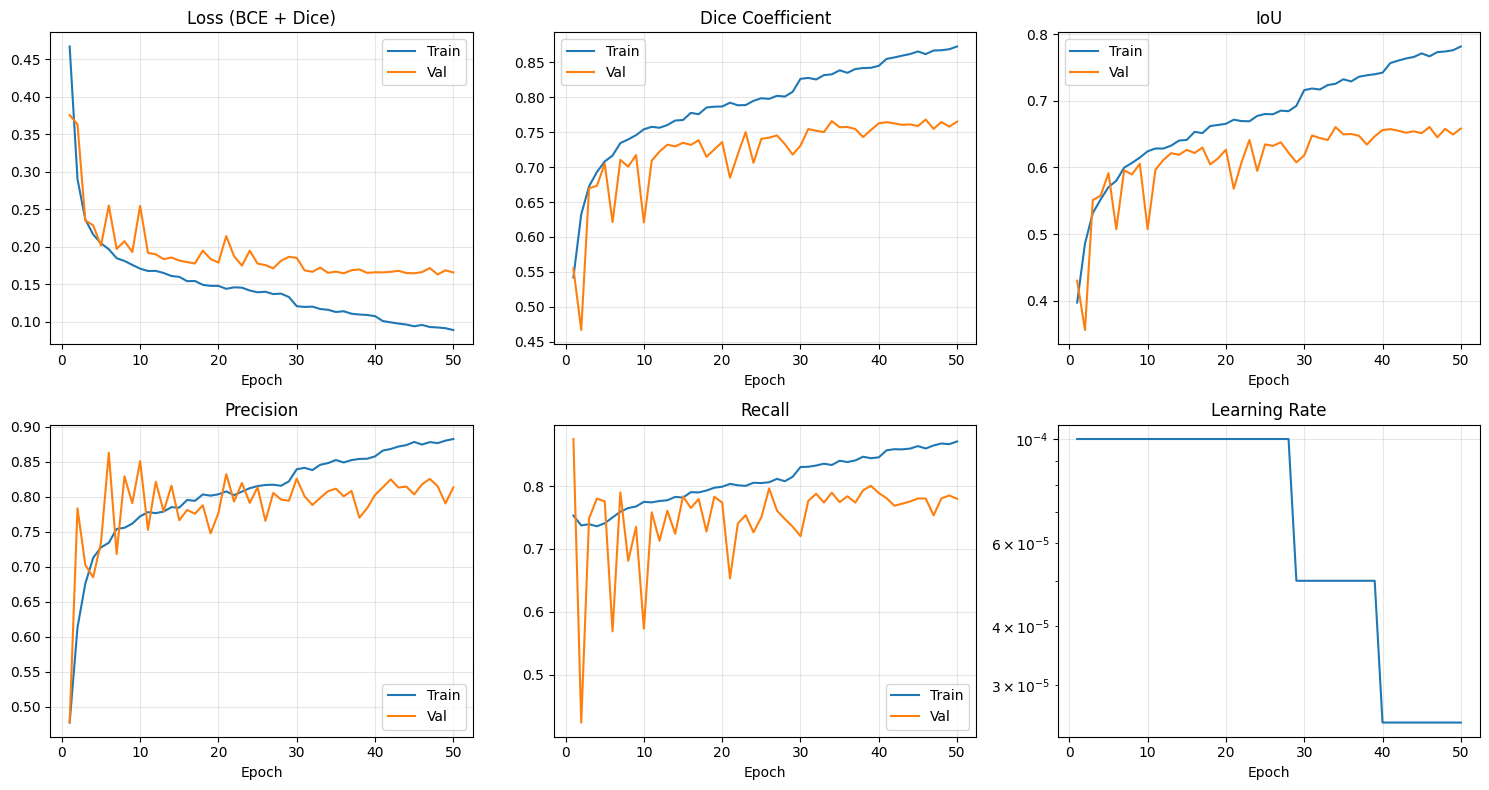


Najlepsze wyniki (epoka 46):
   Dice:      0.7682
   IoU:       0.6608
   Precision: 0.8179
   Recall:    0.7801


In [ ]:
import matplotlib.pyplot as plt

if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)
    print(f"Wczytano historie: {len(history['train_loss'])} epok")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], label='Train')
axes[0, 0].plot(epochs_range, history['val_loss'], label='Val')
axes[0, 0].set_title('Loss (BCE + Dice)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice
axes[0, 1].plot(epochs_range, history['train_dice'], label='Train')
axes[0, 1].plot(epochs_range, history['val_dice'], label='Val')
axes[0, 1].set_title('Dice Coefficient')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[0, 2].plot(epochs_range, history['train_iou'], label='Train')
axes[0, 2].plot(epochs_range, history['val_iou'], label='Val')
axes[0, 2].set_title('IoU')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(epochs_range, history['train_precision'], label='Train')
axes[1, 0].plot(epochs_range, history['val_precision'], label='Val')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(epochs_range, history['train_recall'], label='Train')
axes[1, 1].plot(epochs_range, history['val_recall'], label='Val')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 2].plot(epochs_range, history['lr'])
axes[1, 2].set_title('Learning Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, 'training_history_pytorch.png'), dpi=150)
plt.show()

best_epoch = history['val_iou'].index(max(history['val_iou'])) + 1
print(f"\nNajlepsze wyniki (epoka {best_epoch}):")
print(f"   Dice:      {history['val_dice'][best_epoch-1]:.4f}")
print(f"   IoU:       {max(history['val_iou']):.4f}")
print(f"   Precision: {history['val_precision'][best_epoch-1]:.4f}")
print(f"   Recall:    {history['val_recall'][best_epoch-1]:.4f}")

In [ ]:
TEST_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/test/images/tiled')
TEST_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/test/masks/tiled')

print("Przygotowanie zbioru testowego...")
test_pairs = get_tile_pairs(TEST_IMG_PATH, TEST_MASK_PATH)
print(f"   Znaleziono: {len(test_pairs)} par tile'ow")

test_dataset = GraphiteDataset(test_pairs, IMG_SIZE)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nWczytywanie najlepszego modelu...")
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"   Model wczytany (IoU: {checkpoint['best_iou']:.4f})")

print("\nEwaluacja na zbiorze testowym...")
test_loss, test_iou, test_dice, test_prec, test_rec = validate(model, test_loader, criterion, DEVICE, use_amp)

print(f"\nWyniki na zbiorze testowym:")
print(f"   Loss:      {test_loss:.4f}")
print(f"   Dice:      {test_dice:.4f}")
print(f"   IoU:       {test_iou:.4f}")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:    {test_rec:.4f}")

Przygotowanie zbioru testowego...
   Znaleziono: 4928 par tile'ow

Wczytywanie najlepszego modelu...
   Model wczytany (IoU: 0.6608)

Ewaluacja na zbiorze testowym...



Wyniki na zbiorze testowym:
   Loss:      0.1665
   Dice:      0.7672
   IoU:       0.6665
   Precision: 0.8113
   Recall:    0.7806


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

FULL_TEST_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/test/images/raw')
FULL_TEST_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/test/masks/raw')

def predict_full_image(model, image_path, mask_path, device, tile_size=256, overlap=64):
    img = Image.open(image_path).convert('RGB')
    mask = Image.open(mask_path).convert('L')
    
    img_np = np.array(img)
    mask_np = np.array(mask)
    h, w = img_np.shape[:2]
    
    pred_sum = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
    
    model.eval()
    step = tile_size - overlap
    
    with torch.no_grad():
        for y in range(0, h, step):
            for x in range(0, w, step):
                y_end = min(y + tile_size, h)
                x_end = min(x + tile_size, w)
                y_start = max(0, y_end - tile_size)
                x_start = max(0, x_end - tile_size)
                
                tile = img_tensor[:, y_start:y_end, x_start:x_end]
                
                if tile.shape[1] < tile_size or tile.shape[2] < tile_size:
                    padded = torch.zeros(3, tile_size, tile_size)
                    padded[:, :tile.shape[1], :tile.shape[2]] = tile
                    tile = padded
                
                tile_batch = tile.unsqueeze(0).to(device)
                
                if use_amp:
                    with torch.amp.autocast('cuda'):
                        logits = model(tile_batch)
                else:
                    logits = model(tile_batch)
                
                pred_tile = torch.sigmoid(logits).squeeze().cpu().numpy()
                actual_h = y_end - y_start
                actual_w = x_end - x_start
                pred_sum[y_start:y_end, x_start:x_end] += pred_tile[:actual_h, :actual_w]
                count[y_start:y_end, x_start:x_end] += 1
    
    pred_avg = pred_sum / np.maximum(count, 1)
    return img_np, mask_np, pred_avg


def find_test_images_with_graphite(img_dir, mask_dir, min_ratio=0.005, max_images=5, randomize=True):
    results = []
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') and os.path.isfile(os.path.join(img_dir, f))]
    
    for img_file in img_files:
        img_path = os.path.join(img_dir, img_file)
        mask_name = img_file.replace('.jpg', '_mask.jpg')
        mask_path = os.path.join(mask_dir, mask_name)
        
        if not os.path.exists(mask_path):
            mask_path = os.path.join(mask_dir, img_file)
        if not os.path.exists(mask_path):
            mask_path = os.path.join(mask_dir, mask_name.replace('.jpg', '.png'))
        
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert('L'))
            ratio = (mask > 127).mean()
            if ratio > min_ratio:
                results.append({'img_path': img_path, 'mask_path': mask_path, 'ratio': ratio})
    
    if randomize and len(results) > max_images:
        import random
        results = random.sample(results, max_images)
    else:
        results = results[:max_images]
    
    return results


print("Szukam zdjec testowych z grafitem...")
test_images = find_test_images_with_graphite(FULL_TEST_IMG_PATH, FULL_TEST_MASK_PATH, max_images=5, randomize=True)
print(f"   Znaleziono {len(test_images)} zdjec")

for i, info in enumerate(test_images):
    print(f"   {i+1}. {os.path.basename(info['img_path'])} - {info['ratio']*100:.1f}% grafitu")

if len(test_images) > 0:
    n_images = len(test_images)
    fig, axes = plt.subplots(n_images, 4, figsize=(20, 5*n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)
    
    print("\nGenerowanie predykcji...")
    
    for i, info in enumerate(test_images):
        print(f"   [{i+1}/{n_images}] {os.path.basename(info['img_path'])}...", end=' ')
        
        img_np, mask_np, pred = predict_full_image(model, info['img_path'], info['mask_path'], DEVICE)
        pred_binary = (pred > 0.5).astype(np.uint8) * 255
        
        # Metryki
        tp = ((pred > 0.5) & (mask_np > 127)).sum()
        fp = ((pred > 0.5) & (mask_np <= 127)).sum()
        fn = ((pred <= 0.5) & (mask_np > 127)).sum()
        
        iou = tp / max(tp + fp + fn, 1)
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        dice = 2*tp / max(2*tp + fp + fn, 1)
        
        print(f"Dice: {dice:.4f} | IoU: {iou:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Obraz: {os.path.basename(info["img_path"])}', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title(f'Maska GT ({info["ratio"]*100:.1f}%)', fontsize=10)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred, cmap='hot', vmin=0, vmax=1)
        axes[i, 2].set_title('Mapa prawdopodobienstwa', fontsize=10)
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(pred_binary, cmap='gray')
        axes[i, 3].set_title(f'Predykcja (IoU: {iou:.4f})', fontsize=10)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODELS_PATH, 'predictions_pytorch.png'), dpi=150)
    plt.show()
    print("\nWizualizacja zapisana!")
else:
    print("Nie znaleziono zdjec z grafitem!")

NameError: name 'DATA_PATH' is not defined